# Jupyter Notebook Template
This template can be used for the weekly coding exercises, and for your coursework.

# Task 1.1 – Classification

## Import libraries

In [1]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import itertools  
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier
import seaborn as sns 
from sklearn.metrics import precision_recall_fscore_support
%matplotlib inline

## Prepare neccasary functions to plot confusion matrix

In [2]:
def plot_confusion_matrix(predicted_labels_list, y_test_list):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list)
    np.set_printoptions(precision=2)
    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=["0","1"], title='Confusion matrix, without normalization')
    plt.show()

In [3]:
def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cnf_matrix = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        plt.text(j, i, format(cnf_matrix[i, j], fmt), horizontalalignment="center",
                 color="white" if cnf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix

## Prepare the dataset 

In [4]:
# import dataset
full_train=pd.read_csv('pop_failures.dat',sep='\s+')
column_names=full_train.columns

# drop first 2 column since they are not model imputs
full_train=full_train.drop('Study',axis=1)
full_train=full_train.drop('Run',axis=1)

# devide dataset into train and a test set
train_set, test_set = train_test_split(full_train, test_size=0.2, random_state=42)

# separate features from labels
X_train_unscaled,y_train=train_set[column_names[2:len(column_names)-1]],train_set[column_names[len(column_names)-1]]
X_test_unscaled ,y_test=test_set[column_names[2:len(column_names)-1]],test_set[column_names[len(column_names)-1]]

# normalize the data
scaler = StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train_unscaled))
X_test=pd.DataFrame(scaler.fit_transform(X_test_unscaled))

# restore columns names
X_train.columns=column_names[2:len(column_names)-1]
X_test.columns=column_names[2:len(column_names)-1]


# Random Forest Classifier

In [5]:
rndclf = RandomForestClassifier()
# Train classifier
rndclf.fit(X_train, y_train)

RandomForestClassifier()

In [6]:
# Make predictions on test set
y_pred=rndclf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

# SVC classifier

In [7]:
svcclf = SVC()
# Train classifier
svcclf.fit(X_train, y_train)

SVC()

In [8]:
# Make predictions on test set
y_pred=svcclf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

# MLP classifier

In [9]:
mlpclf = MLPClassifier(hidden_layer_sizes=(150,100,50), max_iter=300,activation = 'relu',solver='adam',random_state=1)

In [10]:
mlpclf.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(150, 100, 50), max_iter=300, random_state=1)

In [11]:
# Make predictions on test set
y_pred=mlpclf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

# Phase 1.2 – Assessment of classification

# Assess Random Forest Classifier

In [12]:
# Make predictions on test set
y_pred=rndclf.predict(X_test)

Confusion matrix, without normalization


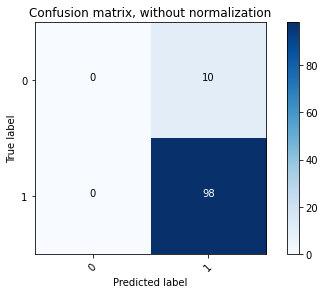

In [13]:
%matplotlib inline
#Confusion matrix on test set
plot_confusion_matrix(y_pred,y_test)

In [14]:
# Calculate precision and recall on test set
precision_recall_fscore_support(y_test, y_pred, average='macro')

project\venv\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.4537037037037037, 0.5, 0.47572815533980584, None)

Confusion matrix, without normalization


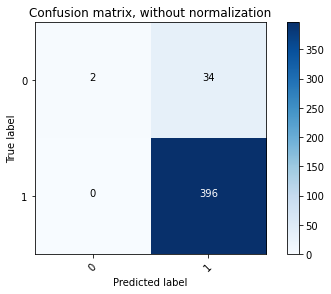

In [15]:
%matplotlib inline
# make predictions on train set
y_pred = cross_val_predict(rndclf, X_train, y_train, cv=10)
conf_mat = confusion_matrix(y_train, y_pred)
# Plot confusion matrix of train set
plot_confusion_matrix(y_pred,y_train)

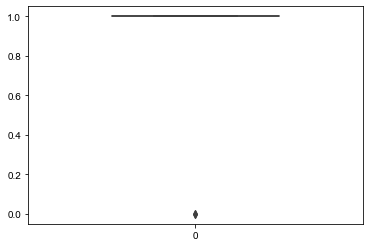

In [16]:
%matplotlib inline
box_data = y_pred #variable representing the data array
box_target = ["0","1"] #variable representing the labels array
sns.boxplot(data = box_data,width=0.5,fliersize=5)
sns.set(rc={'figure.figsize':(2,10)})

# Assess Support Vectors Classifier

In [17]:
# Make predictions on test set
y_pred=svcclf.predict(X_test)

Confusion matrix, without normalization


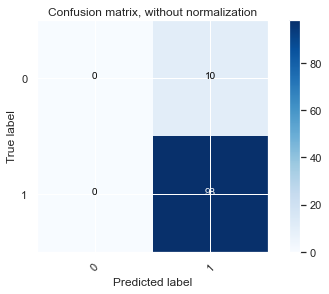

In [18]:
%matplotlib inline
#Confusion matrix on test set
plot_confusion_matrix(y_pred,y_test)

In [19]:
# Calculate precision and recall on test set
precision_recall_fscore_support(y_test, y_pred, average='macro')

project\venv\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.4537037037037037, 0.5, 0.47572815533980584, None)

Confusion matrix, without normalization


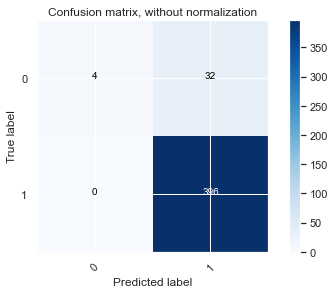

In [20]:
%matplotlib inline
# make predictions on train set
y_pred = cross_val_predict(svcclf, X_train, y_train, cv=10)
conf_mat = confusion_matrix(y_train, y_pred)
# Plot confusion matrix of train set
plot_confusion_matrix(y_pred,y_train)

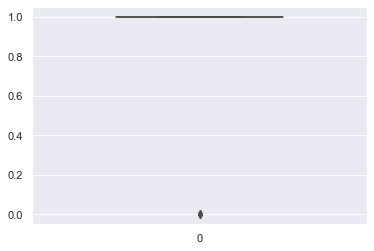

In [21]:
%matplotlib inline
box_data = y_pred #variable representing the data array
box_target = ["0","1"] #variable representing the labels array
sns.boxplot(data = box_data,width=0.5,fliersize=5)
sns.set(rc={'figure.figsize':(2,10)})

# Assess MLP classifier

In [22]:
# Make predictions on test set
y_pred=mlpclf.predict(X_test)

Confusion matrix, without normalization


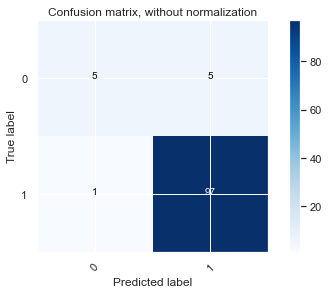

In [23]:
%matplotlib inline
#Confusion matrix on test set
plot_confusion_matrix(y_pred,y_test)

In [24]:
# Calculate precision and recall on test set
precision_recall_fscore_support(y_test, y_pred, average='macro')

(0.892156862745098, 0.7448979591836735, 0.7975000000000001, None)

Confusion matrix, without normalization


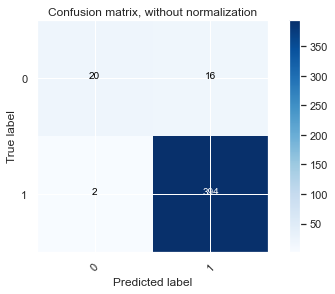

In [25]:
%matplotlib inline
# make predictions on train set
y_pred = cross_val_predict(mlpclf, X_train, y_train, cv=10)
conf_mat = confusion_matrix(y_train, y_pred)
# Plot confusion matrix of train set
plot_confusion_matrix(y_pred,y_train)

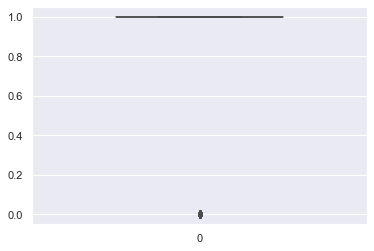

In [26]:
%matplotlib inline
box_data = y_pred #variable representing the data array
box_target = ["0","1"] #variable representing the labels array
sns.boxplot(data = box_data,width=0.5,fliersize=5)
sns.set(rc={'figure.figsize':(2,10)})